# Experiment Design Project: Penguins


## Loading the Data and Splitting the Data


In [60]:
library(palmerpenguins)
library(ggplot2)
library(tidyr)
library(dplyr)
library(reshape2) 

In [61]:
data(package = 'palmerpenguins')
dim(penguins)

[1] 344   8

Data sets in package 'palmerpenguins':

penguins                Size measurements for adult foraging penguins
                        near Palmer Station, Antarctica
penguins_raw (penguins)
                        Penguin size, clutch, and blood isotope data
                        for foraging adults near Palmer Station,
                        Antarctica

In [62]:
head(penguins)

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,NA,NA,NA,NA,NA,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007


We have 344 entries with 8 Columns in the dataset. It looks like some rows are completely full of NAs and need special treatment.


In [63]:
summary(penguins)

      species          island    bill_length_mm  bill_depth_mm  
 Adelie   :152   Biscoe   :168   Min.   :32.10   Min.   :13.10  
 Chinstrap: 68   Dream    :124   1st Qu.:39.23   1st Qu.:15.60  
 Gentoo   :124   Torgersen: 52   Median :44.45   Median :17.30  
                                 Mean   :43.92   Mean   :17.15  
                                 3rd Qu.:48.50   3rd Qu.:18.70  
                                 Max.   :59.60   Max.   :21.50  
                                 NA's   :2       NA's   :2      
 flipper_length_mm  body_mass_g       sex           year     
 Min.   :172.0     Min.   :2700   female:165   Min.   :2007  
 1st Qu.:190.0     1st Qu.:3550   male  :168   1st Qu.:2007  
 Median :197.0     Median :4050   NA's  : 11   Median :2008  
 Mean   :200.9     Mean   :4202                Mean   :2008  
 3rd Qu.:213.0     3rd Qu.:4750                3rd Qu.:2009  
 Max.   :231.0     Max.   :6300                Max.   :2009  
 NA's   :2         NA's   :2                  

From a first glance on the statistics, it looks like the numerical values are all within a reasonable range without significant outliers. The variable _species_ that will be used as a target later in the project suffers from class imblance. The data contains NA-values but very little compared to the whole dataset.


In [64]:
penguins_no_na <- na.omit(penguins)
dim(penguins_no_na)

[1] 333   8

Removing the NAs only reduced the data by 11 Rows, which is acceptable due to the fact that it is <1% of the full dataset. Since we want to do analysis on variables that had NAs (e.g. Anova based on gender) they were of no value for the use-case. The next step will be to split the data and perform further analysis on the Train-Set to gain insights into the domain.


In [65]:
set.seed(123)

n <- nrow(penguins_no_na)
idx <- sample(n) # shuffle data

train_indices <- idx[1:floor(0.7 * n)] # first 70%, train-set
val_indices <- idx[(floor(0.7 * n) + 1):floor(0.85 * n)] # 15% validation-set
test_indices <- idx[(floor(0.85 * n) + 1):n] # 15% test-set

train_set <- penguins_no_na[train_indices, ]
validation_set <- penguins_no_na[val_indices, ]
test_set <- penguins_no_na[test_indices, ]

print(dim(train_set))
print(dim(validation_set))
print(dim(test_set))

[1] 233   8
[1] 50  8
[1] 50  8


## Exploratory Data Analysis


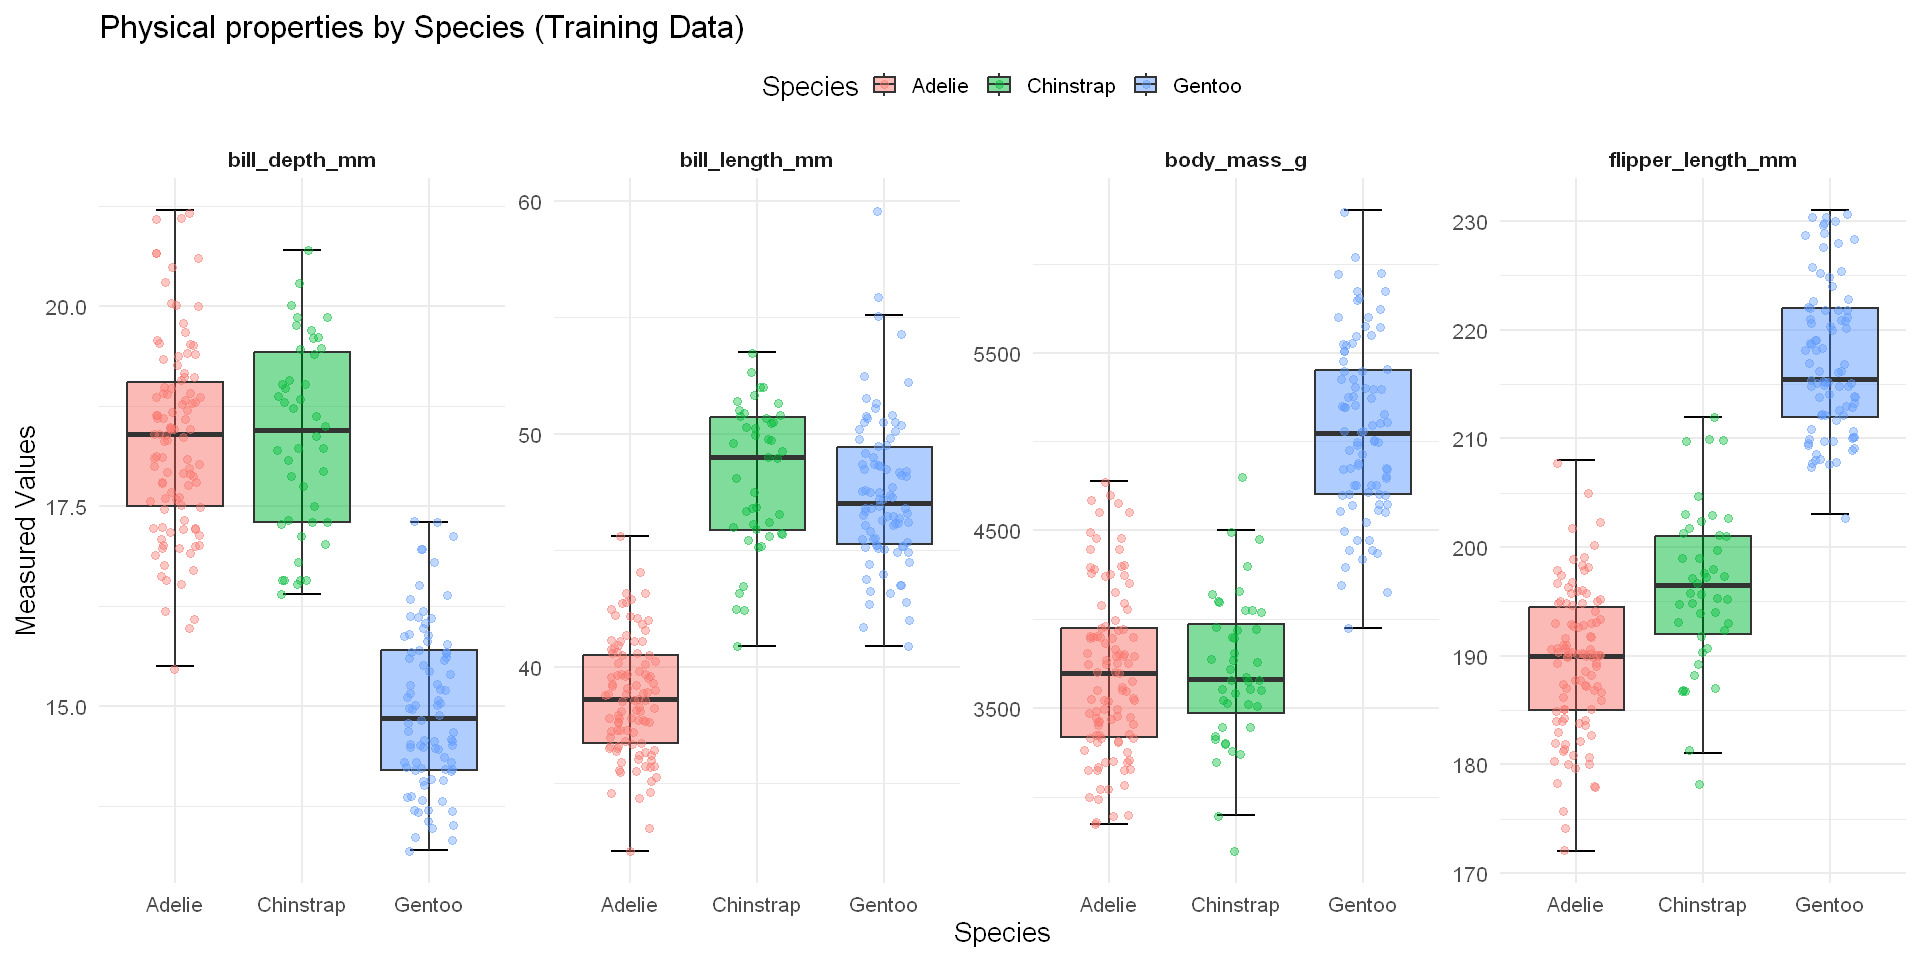

In [66]:
options(repr.plot.width = 16, repr.plot.height = 8) # settings for the notebooks

train_set |>
  pivot_longer(cols = c(bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g),
               names_to = "variable", 
               values_to = "value") |>
  ggplot(aes(x = species, y = value, fill = species)) +
  stat_boxplot(geom = "errorbar", width = 0.3) + 
  geom_boxplot(outlier.shape = NA, alpha = 0.5) +
  geom_jitter(aes(color = species), width = 0.2, alpha = 0.4) + # data points, jitter moves sideways
  facet_wrap(~variable, ncol = 4, scales = "free_y") + # scale plots accordingly to each variable
  theme_minimal(base_size = 16) +
  labs(title = "Physical properties by Species (Training Data)",
       x = "Species",
       y = "Measured Values",
       fill = "Species",
       color = "Species") +
  theme(legend.position = "top", ,strip.text = element_text(face = "bold"))

From the plot we can see that there are very little outliers in the data. Also the plot shows that _Gentoo_ penguins tend to be distinguishable to the others by their _bill depth_, _body mass_ and _flipper length_. On the other hand _Adelie_ and _Chinstrp_ penguins have very similar boxplots overall while the Adelie species tends to have smaller _bill lenght_ compared to the other species.


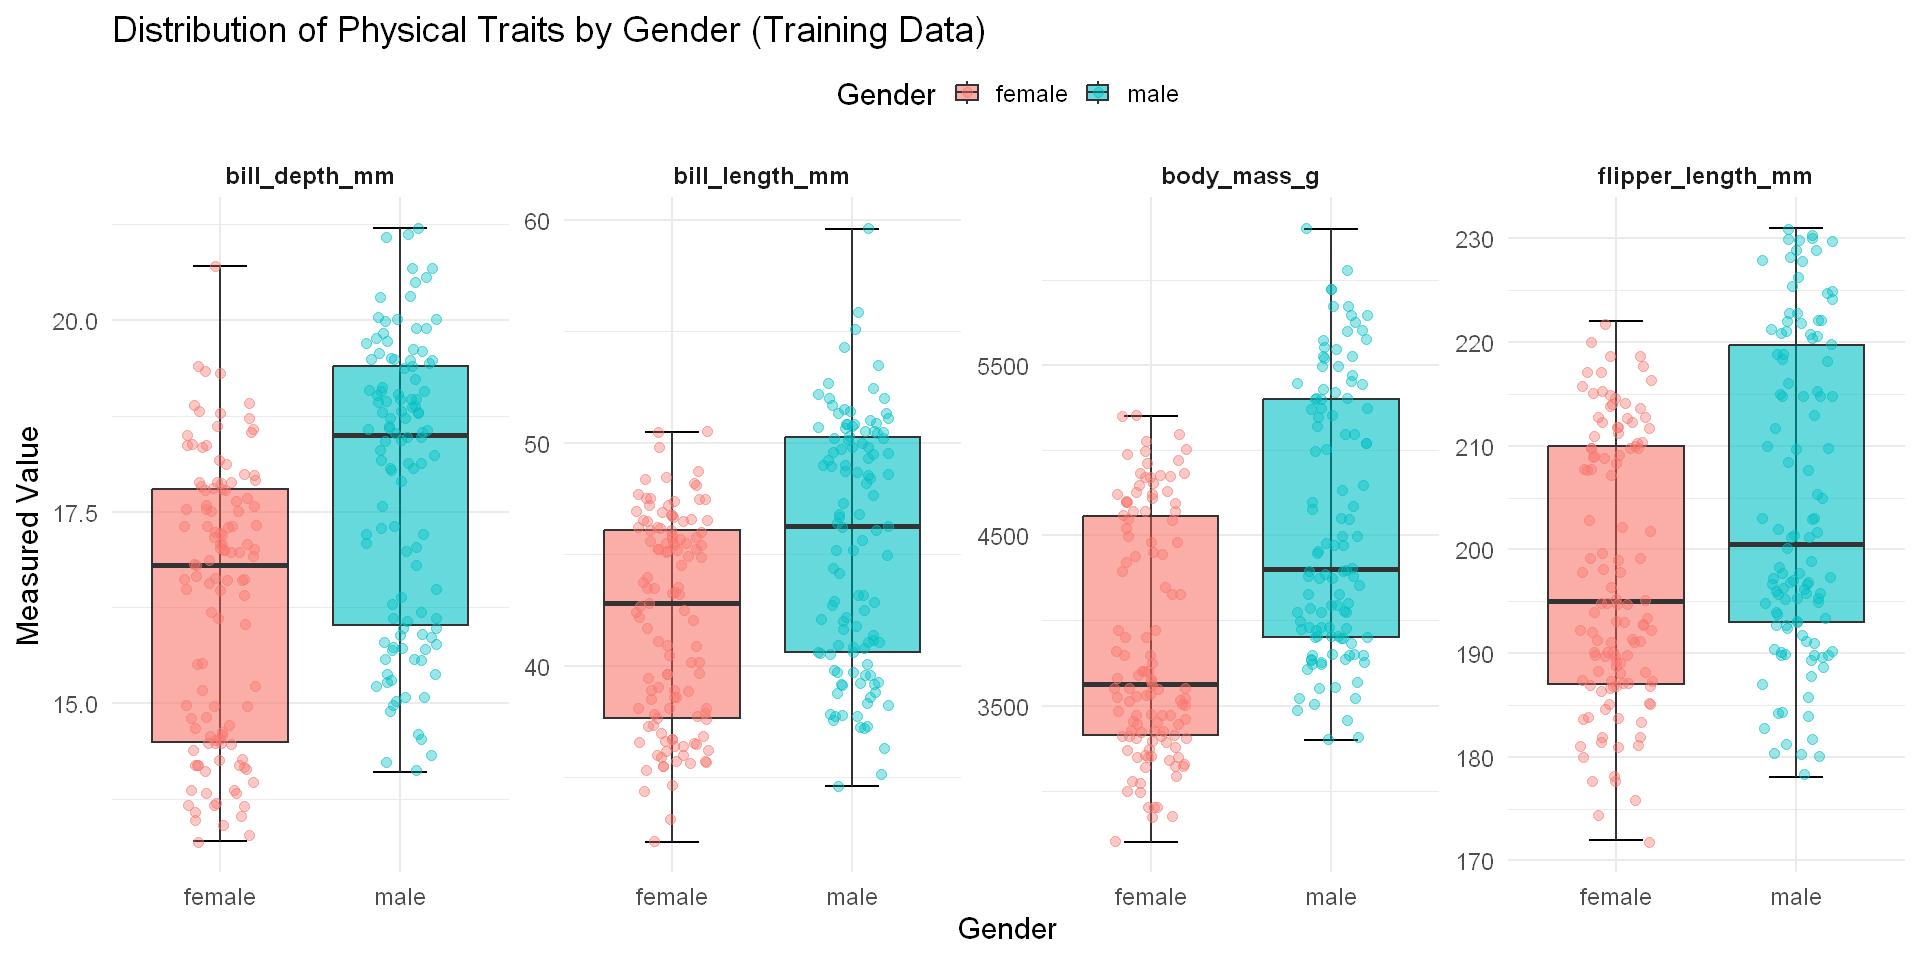

In [67]:
penguins_gender <- train_set |>
  filter(!is.na(sex)) %>%
  pivot_longer(cols = c(bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g),
               names_to = "variable", 
               values_to = "value")

# 3. Create the plot
ggplot(penguins_gender, aes(x = sex, y = value, fill = sex)) +
  stat_boxplot(geom = "errorbar", width = 0.3) + 
  geom_boxplot(outlier.shape = NA, alpha = 0.6) +
  geom_jitter(aes(color = sex), width = 0.2, alpha = 0.4) + 
  facet_wrap(~variable, ncol = 4, scales = "free_y") + 
  theme_minimal(base_size = 18) +
  labs(title = "Distribution of Physical Traits by Gender (Training Data)",
       x = "Gender",
       y = "Measured Value",
       fill = "Gender",
       color = "Gender") +
  theme(legend.position = "top",strip.text = element_text(face = "bold")) # bold headers for features

The plot above shows how the numerical features differ between male and female penguins. It seems that male penguins tend to have larger bill sizes, are heavier and have longer flippers, which concides with the fact that in animal world male animails are generally larger and heavier than females.


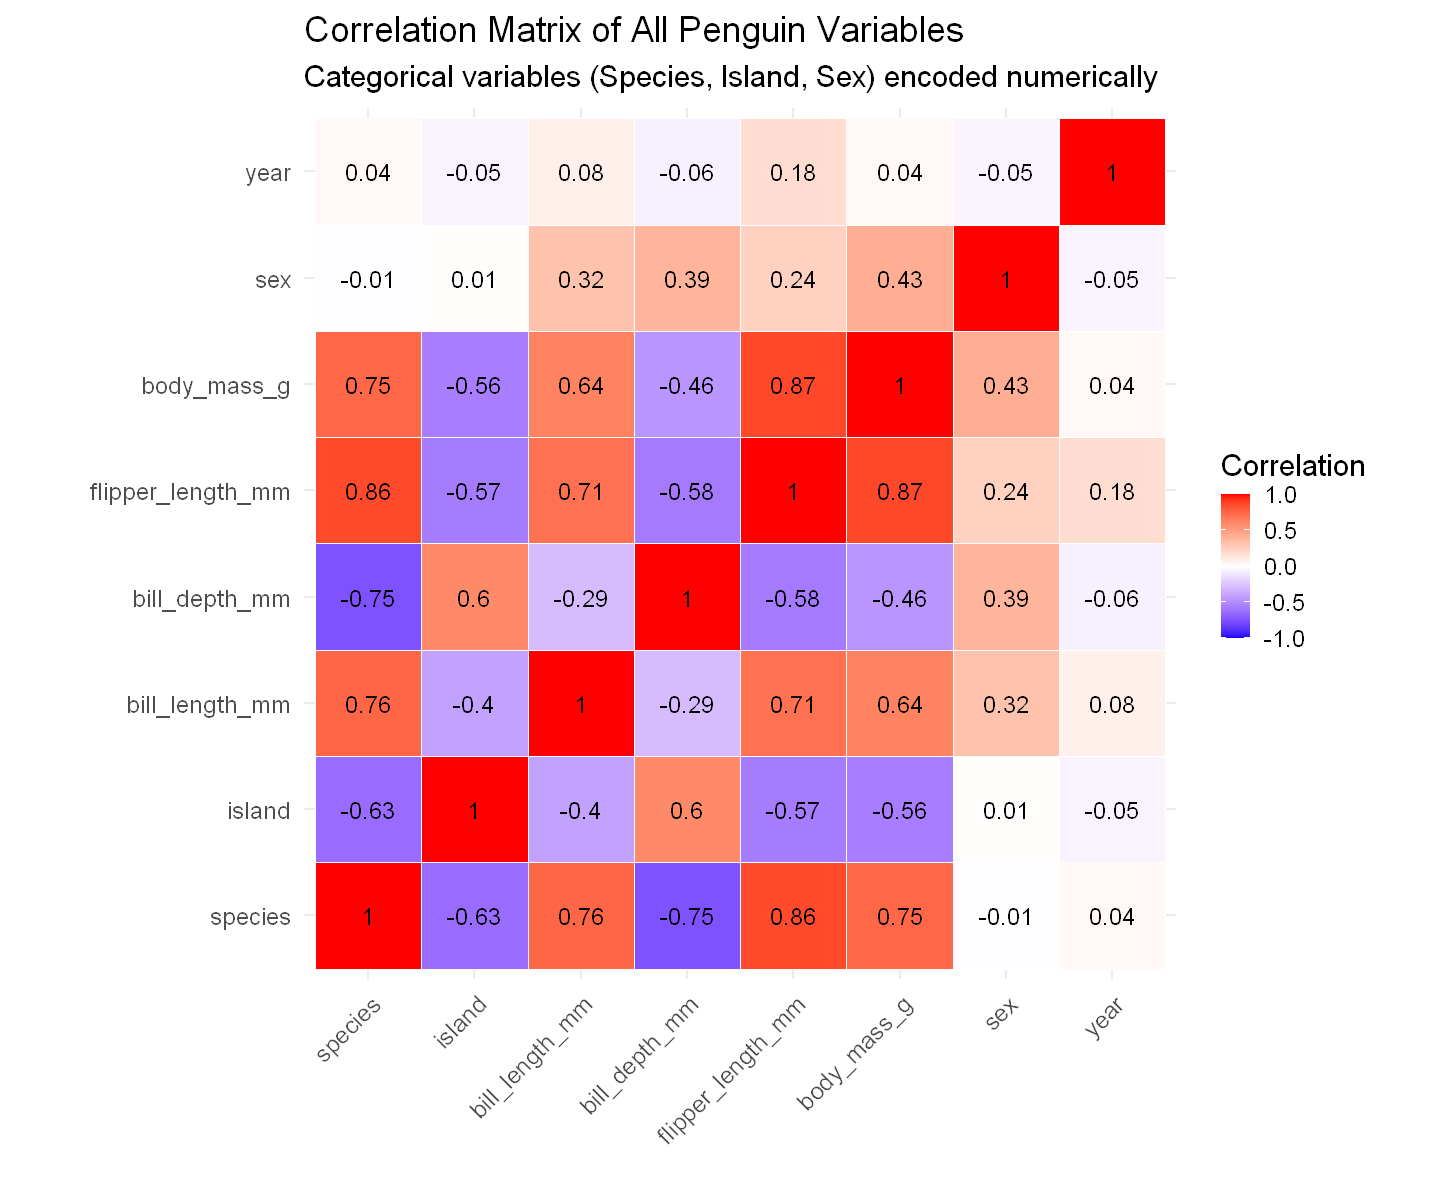

In [71]:
options(repr.plot.width = 12, repr.plot.height = 10)

# convert factors to numerics for  correlation calculation
cor_data <- train_set %>%
  mutate(across(where(is.factor), as.numeric)) |>
  cor(use = "complete.obs")

# melt transforms from wide format into long format, for easier plotting
melted_cor <- melt(cor_data)

ggplot(melted_cor, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile(color = "white") +
  scale_fill_gradient2(low = "blue", high = "red", mid = "white", 
                       midpoint = 0, limit = c(-1,1), space = "Lab", 
                       name="Correlation") +
  theme_minimal(base_size = 18) + 
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1)) +
  coord_fixed() +
  labs(title = "Correlation Matrix of All Penguin Variables",
       subtitle = "Categorical variables (Species, Island, Sex) encoded numerically",
       x = "", y = "") + # x and y need to be specifically set to ""
  geom_text(aes(label = round(value, 2)), color = "black", size = 5)

- year has no correlation => confounding variable => remove
- sex has moderate positive correlation with size, and mass => expected from previous plot
- body mass has strong pos correlation with species (maybe because some species tend to be heavier), bill_length and fillper length
- island has correlation with species and other measurements => maybe some species are more common on some islands => probably confounding variable => remove, also with regards to generalization

Conclusions

- Classification: Remove year, island (we want the model to generalize to other islands) and sex
- Regression: Remove year and island
- Other variables seem to be decent predictors to overall strong correlation.


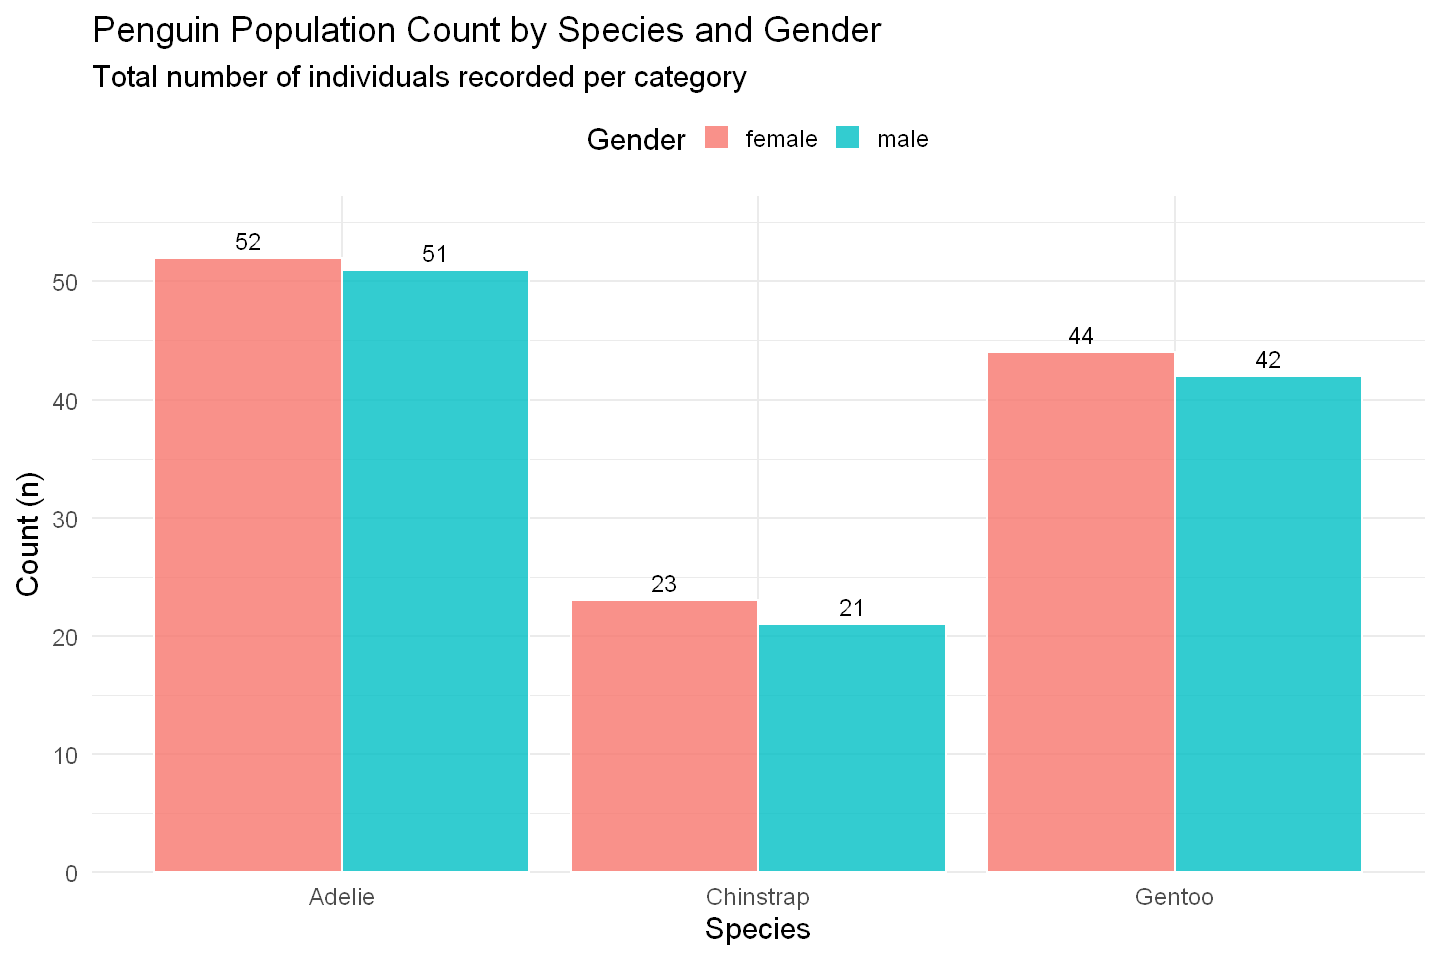

In [ ]:
options(repr.plot.width = 12, repr.plot.height = 8)

ggplot(train_set, aes(x = species, fill = sex)) +
  geom_bar(position = "dodge", color = "white", alpha = 0.8) +
  geom_text(stat = 'count', 
            aes(label = after_stat(count)), 
            position = position_dodge(width = 0.9), 
            vjust = -0.5, 
            size = 5) +
  theme_minimal(base_size = 18) +
  labs(title = "Penguin Population Count by Species and Gender",
       subtitle = "Total number of individuals recorded per category",
       x = "Species",
       y = "Count",
       fill = "Gender") +
  theme(legend.position = "top") +
  scale_y_continuous(expand = expansion(mult = c(0, 0.1))) # adding space for labels above bars

The plot shows the number of samples in the train set for each species, by gender. What stings out the most is that there is a significant imbalance between _Chinstrap_ and other penguins, which needs special care when performing classification (e.g. weigh classes). The difference between male and female penguins within each class is well balanced.


In [69]:
## TODO:
# 1) Correlation 
# 2) Distribution Species 
# 3) Normal Distribution Body mass => Histogram, Denisty, QQ and Test for norm-dist

## ANOVA: Species, mass and gender


## Classification: Species


## Regression: Body Mass
